In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import dataframe_image as dfi
import folium
from folium.plugins import HeatMap
import matplotlib.patches as patches

In [5]:
parent_dir = os.path.dirname(os.getcwd())
bronze_data_path = parent_dir + '/data/1_bronze/data_raw.parquet'
silver_data_path = parent_dir + '/data/2_silver/bus_gps_data.parquet'
gold_data_path = parent_dir + '/data/3_gold/dm_gold_data.parquet'
image_dir = parent_dir + '/images/'

# EDA for bronze layer


In [20]:
df = pd.read_parquet(bronze_data_path, engine='pyarrow')

df.describe(include='all')

,vehicle,speed,datetime,x,y,heading,ignition,aircon,driver,door_up,door_down,working
count,17811310,8.460427e+06,1.781131e+07,1.781131e+07,1.781131e+07,2.225832e+06,14001688,12484093,9166652,1998616,1427177,30057
unique,492,NaN,NaN,NaN,NaN,NaN,1,1,244,1,1,1
top,199e046d2f4657115b402d9ca09006e93ac008abf11452...,NaN,NaN,NaN,NaN,NaN,True,True,88917658b5bff2e1b39bad7d467543609a050fd86e02bd...,True,True,True
freq,78883,NaN,NaN,NaN,NaN,NaN,14001688,12484093,5155664,1998616,1427177,30057
mean,NaN,2.120378e+01,1.742983e+09,1.066611e+02,1.085814e+01,1.859797e+02,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.179291e+01,2.066741e+05,1.868663e-01,7.461159e-01,1.028443e+02,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000e+00,1.742429e+09,1.038424e+02,1.038706e+01,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,1.200000e+01,1.742814e+09,1.066267e+02,1.076927e+01,1.020000e+02,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2.100000e+01,1.742981e+09,1.066691e+02,1.080358e+01,1.740000e+02,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2.900000e+01,1.743156e+09,1.067170e+02,1.084867e+01,2.820000e+02,NaN,NaN,NaN,NaN,NaN,NaN


Số lượng bản ghi: 17811310
Số lượng thuộc tính: 12
vehicle       object
speed        float64
datetime       int64
x            float64
y            float64
heading      float64
ignition      object
aircon        object
driver        object
door_up       object
door_down     object
working       object
dtype: object
Tỷ lệ dữ liệu khuyết (%):
vehicle       0.000000
speed        52.499693
datetime      0.000000
x             0.000000
y             0.000000
heading      87.503266
ignition     21.388780
aircon       29.909181
driver       48.534656
door_up      88.778950
door_down    91.987243
working      99.831248
dtype: float64


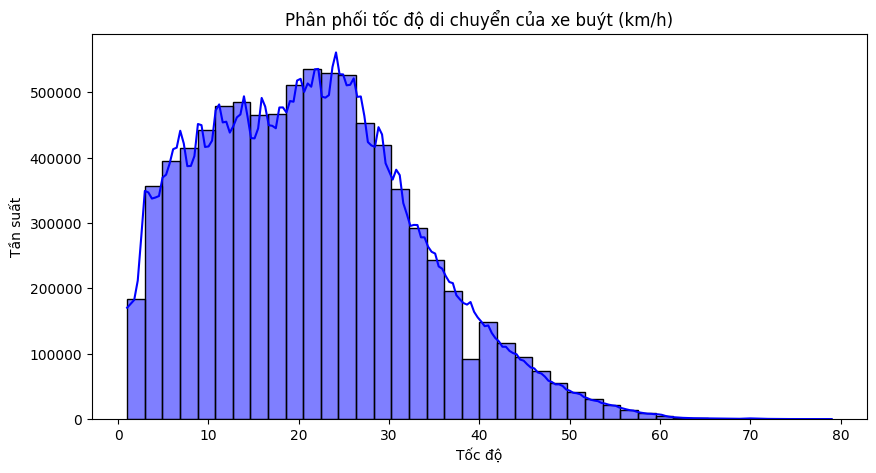

In [ ]:
# 1. In ra số lượng bản ghi và thuộc tính
print(f"Số lượng bản ghi: {df.shape[0]}")
print(f"Số lượng thuộc tính: {df.shape[1]}")
print(df.dtypes)

# 2. Kiểm tra dữ liệu khuyết
print("Tỷ lệ dữ liệu khuyết (%):")
print((df.isnull().sum() / len(df)) * 100)



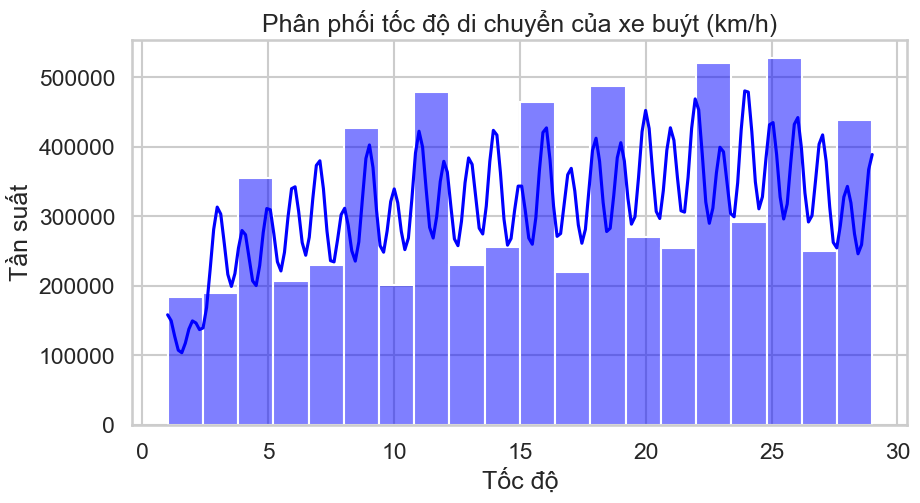

In [ ]:
# 3. Vẽ biểu đồ phân phối tốc độ (bạn lưu ảnh này dán vào báo cáo)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['speed'] < 80]['speed'], bins=40, kde=True, color='blue')
plt.title('Phân phối tốc độ di chuyển của xe buýt (km/h)')
plt.xlabel('Tốc độ')
plt.ylabel('Tần suất')
plt.show()

# EDA for silver layer

In [6]:
sns.set_theme(style="whitegrid", context="talk")
df_eda = pd.read_parquet(silver_data_path, engine='pyarrow')

In [ ]:

dfi.export(df_eda.describe(include='all'), image_dir + 'eda_silver.png', table_conversion='matplotlib')

df_eda = df_eda[((df_eda['door_up'] == True) | (df_eda['door_down'] == True))].copy()
df_eda = df_eda[(df_eda['station_distance'] < 200)]


C:\Users\nguye\AppData\Local\Temp\ipykernel_15112\4277980895.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=12)


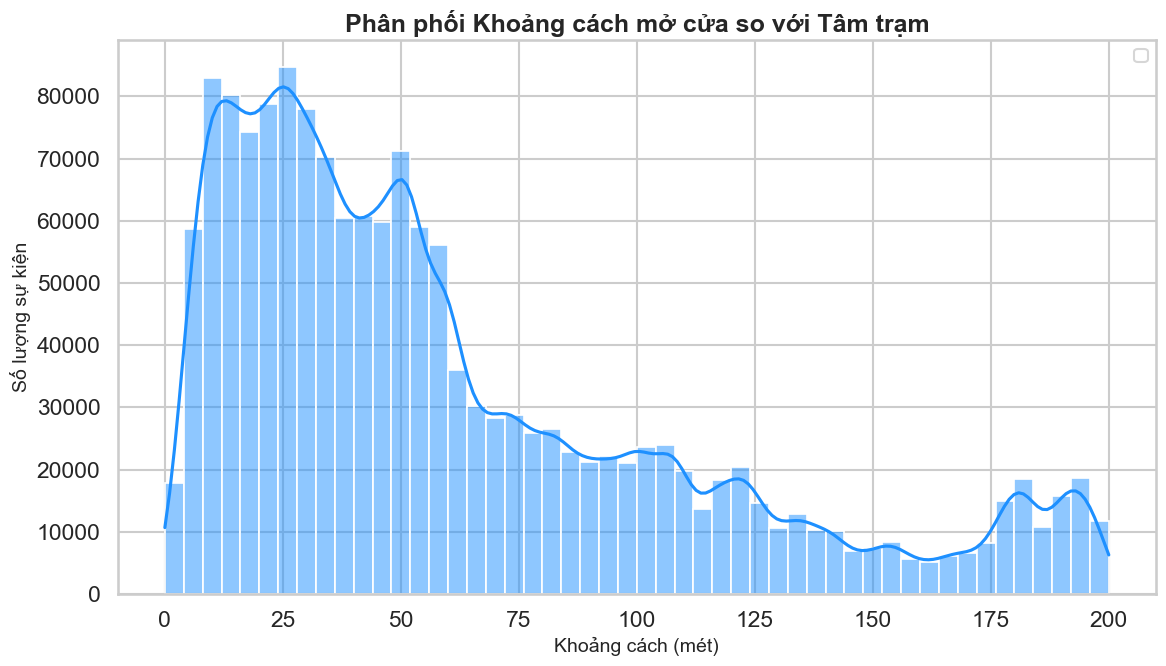

In [22]:
fig1, ax1 = plt.subplots(figsize=(12, 7))

sns.histplot(df_eda['station_distance'], bins=50, kde=True, color="dodgerblue", ax=ax1)

ax1.set_title('Phân phối Khoảng cách mở cửa so với Tâm trạm', fontsize=18, fontweight='bold')
ax1.set_xlabel('Khoảng cách (mét)', fontsize=14)
ax1.set_ylabel('Số lượng sự kiện', fontsize=14)
ax1.legend(fontsize=12)

plt.tight_layout()
plt.show()

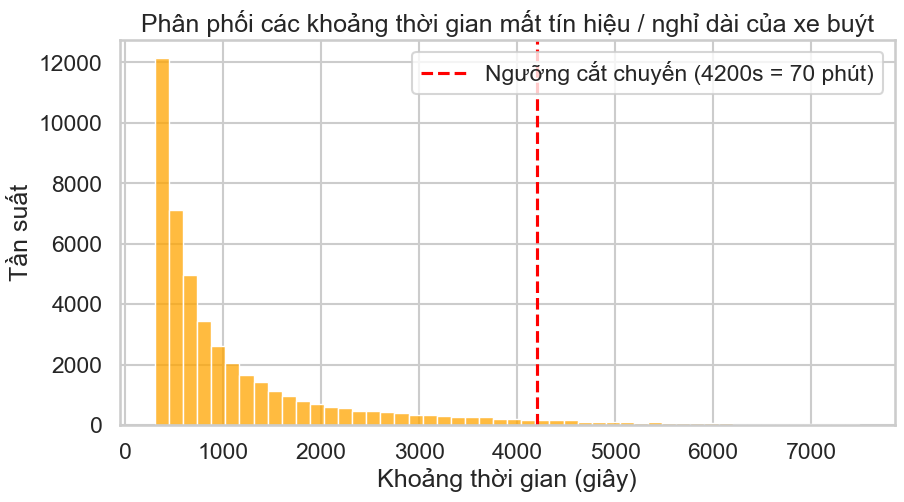

In [19]:
# --- CHỨNG MINH THAM SỐ 4200 GIÂY ---
# Tính khoảng thời gian giữa 2 lần phát GPS liên tiếp của cùng 1 xe
df_eda = df_eda.sort_values(['vehicle', 'datetime'])
time_diffs = df_eda.groupby('vehicle')['datetime'].diff()

# Lọc các khoảng thời gian lớn hơn 5 phút (300s) để loại bỏ nhiễu ping thông thường
gaps = time_diffs[time_diffs > 300]

plt.figure(figsize=(10, 5))
# Vẽ histogram cho các khoảng nghỉ từ 5 phút đến 120 phút (7200 giây)
sns.histplot(gaps[gaps < 7500], bins=50, color='orange')
plt.axvline(4200, color='red', linestyle='--', label='Ngưỡng cắt chuyến (4200s = 70 phút)')
plt.title('Phân phối các khoảng thời gian mất tín hiệu / nghỉ dài của xe buýt')
plt.xlabel('Khoảng thời gian (giây)')
plt.ylabel('Tần suất')
plt.legend()
plt.show()

In [17]:
df_eda.describe(include='all')

,vehicle,speed,datetime,x,y,driver,door_up,door_down,realtime,current_station,station_distance,is_terminal
count,1579393,1.579393e+06,1.579393e+06,1.579393e+06,1.579393e+06,1137719,1579393,1579393,1579393,1579393,1.579393e+06,1579393
unique,230,NaN,NaN,NaN,NaN,203,1,2,622305,780,NaN,2
top,be4cc10903f3fadaf01920ba7f5904693e3184f6859dc9...,NaN,NaN,NaN,NaN,88917658b5bff2e1b39bad7d467543609a050fd86e02bd...,True,True,25-03-2025 22:01:26,Bãi xe buýt Phổ Quang,NaN,True
freq,32752,NaN,NaN,NaN,NaN,779351,1579393,1103447,14,226056,NaN,855133
mean,NaN,4.448880e-01,1.742964e+09,1.067059e+02,1.081114e+01,NaN,NaN,NaN,NaN,NaN,6.160993e+01,NaN
std,NaN,3.011425e+00,2.212122e+05,6.162246e-02,4.577230e-02,NaN,NaN,NaN,NaN,NaN,4.981269e+01,NaN
min,NaN,0.000000e+00,1.742429e+09,1.065906e+02,1.070248e+01,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN
25%,NaN,0.000000e+00,1.742786e+09,1.066671e+02,1.076995e+01,NaN,NaN,NaN,NaN,NaN,2.406962e+01,NaN
50%,NaN,0.000000e+00,1.742964e+09,1.066915e+02,1.080885e+01,NaN,NaN,NaN,NaN,NaN,4.684375e+01,NaN
75%,NaN,0.000000e+00,1.743152e+09,1.067707e+02,1.085209e+01,NaN,NaN,NaN,NaN,NaN,8.669484e+01,NaN


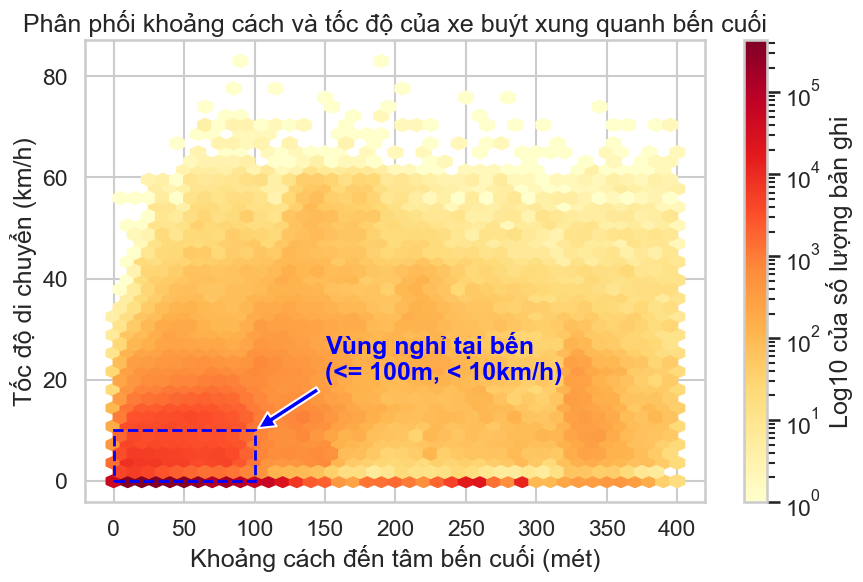

In [19]:
# 2. Lọc các điểm xung quanh bến cuối (ví dụ dưới 1000m) để xem phân phối
df_terminal = df_eda[(df_eda['is_terminal'] == True) & (df_eda['station_distance'] <= 400)].copy()

# 3. Vẽ biểu đồ phân phối mật độ 2D (Hexbin plot)
plt.figure(figsize=(10, 6))
hb = plt.hexbin(df_terminal['station_distance'], df_terminal['speed'], 
                gridsize=40, cmap='YlOrRd', bins='log')

plt.colorbar(hb, label='Log10 của số lượng bản ghi')

# 4. Vẽ một hình chữ nhật (Bounding Box) thể hiện ngưỡng bạn đã chọn
rect = patches.Rectangle((0, 0), 100, 10, linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
plt.gca().add_patch(rect)

plt.title('Phân phối khoảng cách và tốc độ của xe buýt xung quanh bến cuối')
plt.xlabel('Khoảng cách đến tâm bến cuối (mét)')
plt.ylabel('Tốc độ di chuyển (km/h)')
plt.annotate('Vùng nghỉ tại bến\n(<= 100m, < 10km/h)', xy=(100, 10), xytext=(150, 20),
             arrowprops=dict(facecolor='blue', shrink=0.05), color='blue', weight='bold')

plt.show()

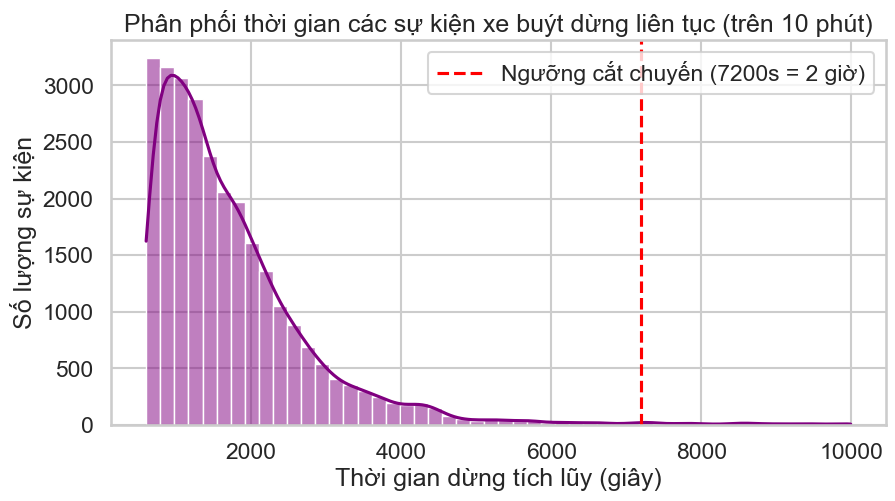

In [17]:

df = df_eda.sort_values(by=['vehicle', 'datetime']).copy()
df['time_diff'] = df.groupby('vehicle')['datetime'].diff()
df['is_stationary'] = df['speed'] < 5
df['move_trigger'] = (df['is_stationary'] == False).cumsum()

# Lọc bỏ các dòng đang di chuyển, chỉ tính những đoạn đứng im
df_stationary = df[df['is_stationary'] == True].copy()
df_stationary['stationary_duration'] = df_stationary.groupby(['vehicle', 'move_trigger'])['time_diff'].cumsum().fillna(0)

# Gom nhóm để lấy tổng thời gian đứng im dài nhất của mỗi chu kỳ dừng
max_idle_events = df_stationary.groupby(['vehicle', 'move_trigger'])['stationary_duration'].max()

# Lọc các sự kiện dừng lâu hơn 10 phút (600s) để loại bỏ nhiễu đèn đỏ thông thường
condition = (max_idle_events > 600) & (max_idle_events < 10000)
long_idle_events = max_idle_events[condition]

plt.figure(figsize=(10, 5))
# Vẽ biểu đồ KDE kết hợp Histogram
sns.histplot(long_idle_events, bins=50, kde=True, color='purple')
plt.axvline(7200, color='red', linestyle='--', label='Ngưỡng cắt chuyến (7200s = 2 giờ)')

plt.title('Phân phối thời gian các sự kiện xe buýt dừng liên tục (trên 10 phút)')
plt.xlabel('Thời gian dừng tích lũy (giây)')
plt.ylabel('Số lượng sự kiện')
plt.legend()
plt.show()

# EDA for gold layer

In [ ]:
df_eda = pd.read_parquet(gold_data_path, engine='pyarrow')
dfi.export(df_eda.describe(include='all'), image_dir + 'eda_silver.png', table_conversion='matplotlib')
df_eda = df_eda[((df_eda['door_up'] == True) | (df_eda['door_down'] == True))].copy()
df_eda = df_eda[(df_eda['avg_speed'] < 100)]
p95_distance = df_eda['avg_speed'].quantile(0.95)

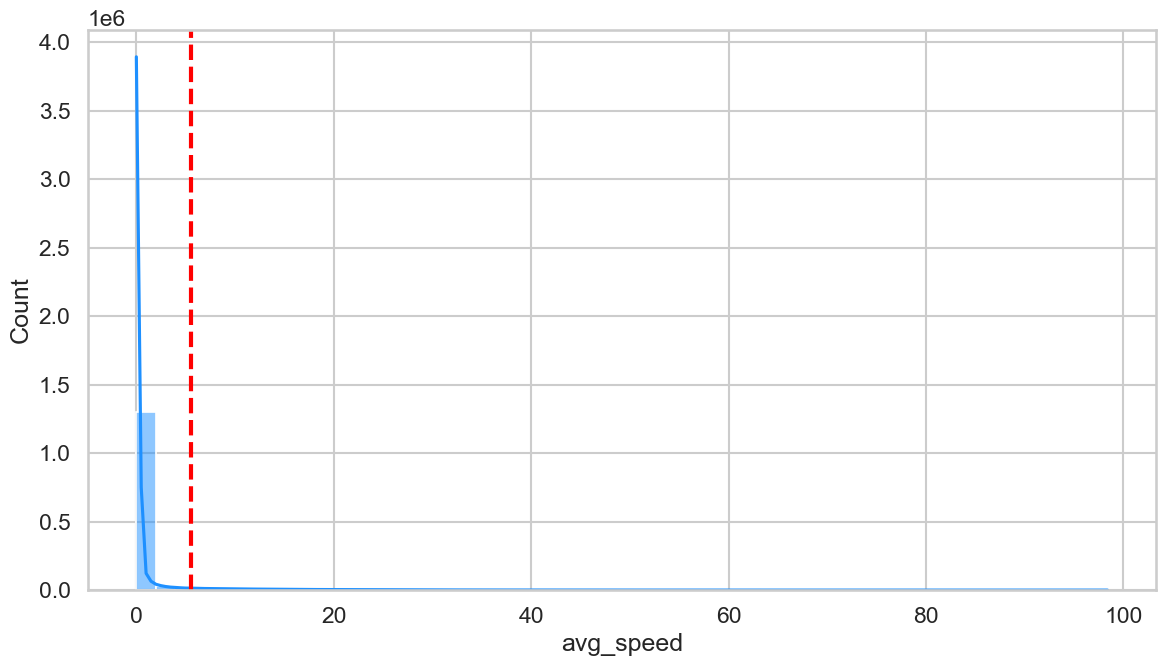

In [ ]:
fig1, ax1 = plt.subplots(figsize=(12, 7))
sns.histplot(df_eda['avg_speed'], bins=50, kde=True, color="dodgerblue", ax=ax1)
ax1.axvline(p95_distance, color='red', linestyle='--', linewidth=3, 
            label=f'Ngưỡng P95: {p95_distance:.1f} m')
plt.tight_layout()
plt.show()

In [ ]:
df_eda = pd.read_parquet(gold_data_path, engine='pyarrow')
dfi.export(df_eda.describe(include='all'), image_dir + 'eda_silver.png', table_conversion='matplotlib')
df_eda = df_eda[((df_eda['door_up'] == True) | (df_eda['door_down'] == True))].copy()
df_eda = df_eda[(df_eda['speed'] < 100)]
p95_distance = df_eda['speed'].quantile(0.95)

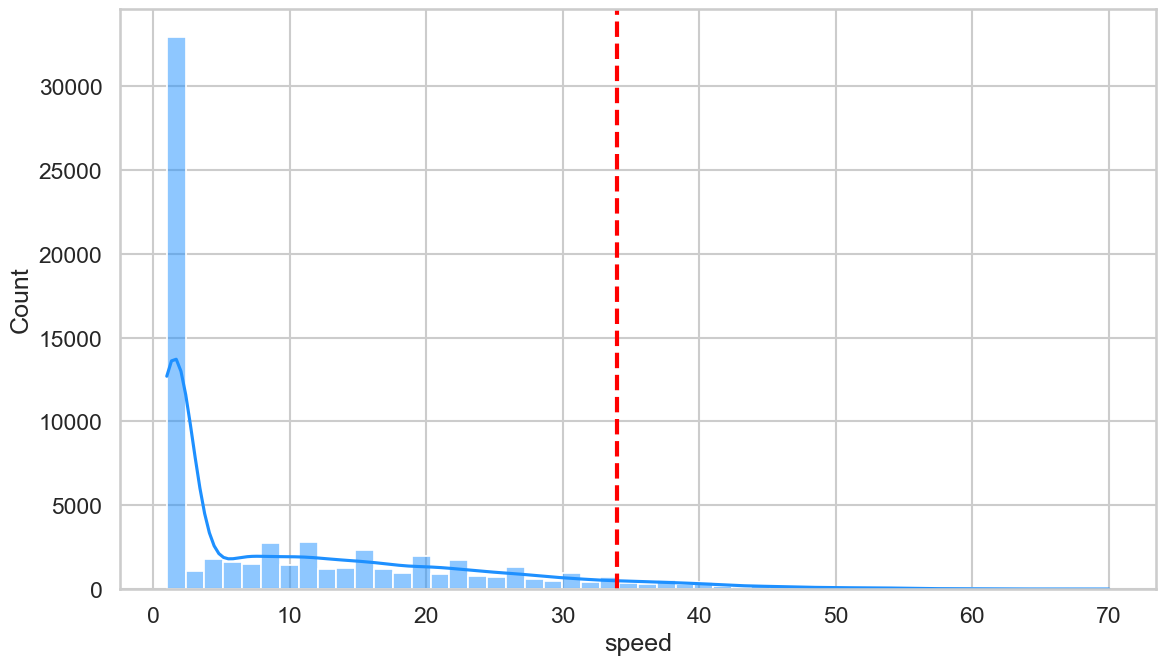

In [ ]:
fig1, ax1 = plt.subplots(figsize=(12, 7))
sns.histplot(df_eda['speed'], bins=50, kde=True, color="dodgerblue", ax=ax1)
ax1.axvline(p95_distance, color='red', linestyle='--', linewidth=3, 
            label=f'Ngưỡng P95: {p95_distance:.1f} m')
plt.tight_layout()
plt.show()

In [ ]:
def method_3_visual_heatmap(jam_df, output_html= image_dir + "/blackspots_heatmap.html"):
    print("Cách 3: Phân tích Điểm đen bằng Thị giác (Heatmap)...")
    
    # Lấy tọa độ trung tâm TP.HCM
    m = folium.Map(location=[10.7769, 106.7009], zoom_start=12, tiles='CartoDB dark_matter')
    heat_data = jam_df[['y', 'x']].values.tolist()
    
    # Thêm Heatmap
    HeatMap(
        heat_data,
        radius=15, # Độ to của Điểm đen
        blur=10,   # Độ hòa trộn
        max_zoom=1,
        gradient={0.4: 'blue', 0.65: 'yellow', 1.0: 'red'} # Điểm đen nhất sẽ có màu đỏ
    ).add_to(m)
    
    m.save(output_html)
    print(f"Đã xuất bản đồ. Vui lòng mở file {output_html} để xác định Điểm đen bằng mắt thường.")
df_eda = pd.read_parquet(silver_data_path, engine='pyarrow')
method_3_visual_heatmap(df_eda)

Cách 3: Phân tích Điểm đen bằng Thị giác (Heatmap)...
Đã xuất bản đồ. Vui lòng mở file d:\Bus-Status-Analysis-Prediction/images//blackspots_heatmap.html để xác định Điểm đen bằng mắt thường.
